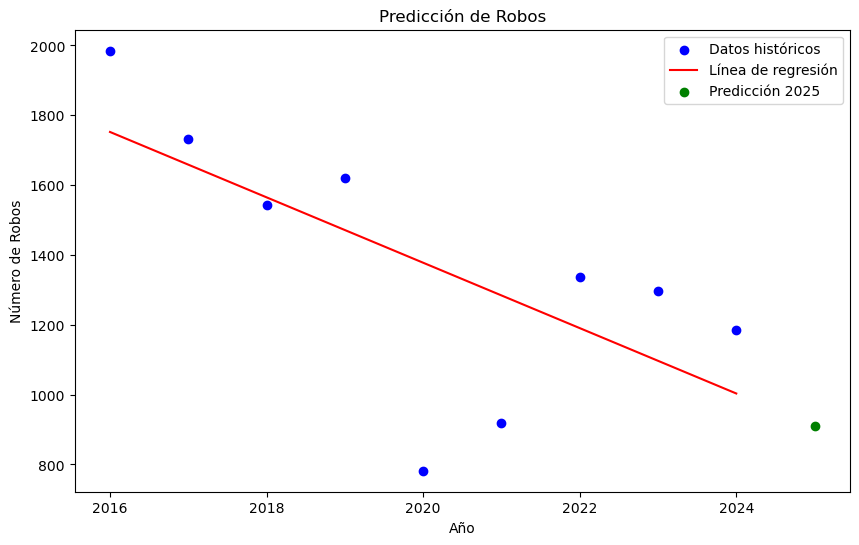

Predicción de robos para 2025: 909.611111111124
Coeficiente de pendiente: -93.63333333333334
Intercepto: 190517.11111111112


In [ ]:
# importamos las librerias pandas para el dataframe, numpy para los calculos estadisticos, sktlearn para la regresion lineal, matplot para

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Creamos un data frame con los datos obtenidos de la base de datos de la Fiscalia


datos = pd.DataFrame({
    'año': [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'numero_robos': [1985, 1732, 1543, 1620, 782, 918, 1338, 1298, 1184]
})

# Definimos los valores de (X) = año y (Y) = número de robos

X = datos['año'].values.reshape(-1, 1)
y = datos['numero_robos'].values

# Entrenar y crear la regresión lineal

modelo = LinearRegression()
modelo.fit(X, y)

# Asigno en uan varible de prediccion_20225 el valor que se va a predecir

prediccion_2025 = modelo.predict([[2025]])[0]

# Se realiza una visualización de los datos con matplot para visualizarlos en un gráfico

plt.figure(figsize=(10, 6))
plt.scatter(datos['año'], datos['numero_robos'], color='blue', label='Datos históricos')
plt.plot(datos['año'], modelo.predict(X), color='red', label='Línea de regresión')
plt.scatter(2025, prediccion_2025, color='green', label='Predicción 2025')
plt.title('Predicción de Robos')
plt.xlabel('Año')
plt.ylabel('Número de Robos')
plt.legend()
plt.show()

# Imprimimos los resultados obtenidos de la regresion lineal

print(f"Predicción de robos para 2025: {prediccion_2025}")
print(f"Coeficiente de pendiente: {modelo.coef_[0]}")
print(f"Intercepto: {modelo.intercept_}")

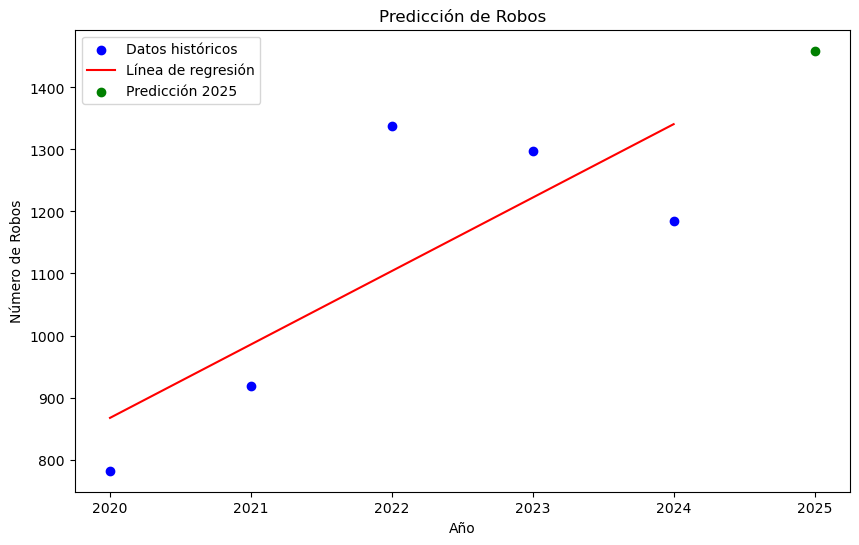

Predicción de robos para 2025: 1459.1999999999825
Coeficiente de pendiente: 118.40000000000002
Intercepto: -238300.80000000005


In [ ]:
# Creamos un data frame con los datos obtenidos de la base de datos de la Fiscalia


datos = pd.DataFrame({
    'año': [2020, 2021, 2022, 2023, 2024],
    'numero_robos': [782, 918, 1338, 1298, 1184]
})

# Definimos los valores de (X) = año y (Y) = número de robos

X = datos['año'].values.reshape(-1, 1)
y = datos['numero_robos'].values

# Entrenar y crear la regresión lineal

modelo = LinearRegression()
modelo.fit(X, y)

# Asigno en uan varible de prediccion_20225 el valor que se va a predecir

prediccion_2025 = modelo.predict([[2025]])[0]

# Se realiza una visualización de los datos con matplot para visualizarlos en un gráfico

plt.figure(figsize=(10, 6))
plt.scatter(datos['año'], datos['numero_robos'], color='blue', label='Datos históricos')
plt.plot(datos['año'], modelo.predict(X), color='red', label='Línea de regresión')
plt.scatter(2025, prediccion_2025, color='green', label='Predicción 2025')
plt.title('Predicción de Robos')
plt.xlabel('Año')
plt.ylabel('Número de Robos')
plt.legend()
plt.show()

# Imprimimos los resultados obtenidos de la regresion lineal

print(f"Predicción de robos para 2025: {prediccion_2025}")
print(f"Coeficiente de pendiente: {modelo.coef_[0]}")
print(f"Intercepto: {modelo.intercept_}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


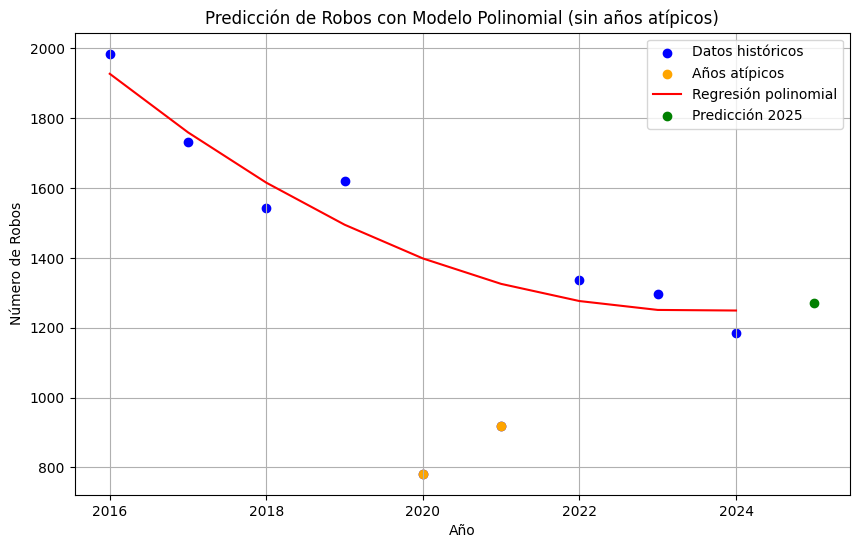

Predicción de robos para 2025 (modelo polinomial): 1271.50


In [4]:
# Creamos un data frame con los datos obtenidos de la base de datos de la Fiscalia

datos = pd.DataFrame({
    'año': [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'numero_robos': [1985, 1732, 1543, 1620, 782, 918, 1338, 1298, 1184]
})

# Eliminamos los años atípicos de pandemia (2019, 2020 y 2021)

datos_filtrados = datos[~datos['año'].isin([2019,2020, 2021])]

# Filtramos los años y sus valores con los numeros de robos

X = datos_filtrados['año'].values.reshape(-1, 1)
y = datos_filtrados['numero_robos'].values

# Aplicamos transformación polinomial de grado 2

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Entrenamos modelo de regresión polinomial

modelo_poly = LinearRegression()
modelo_poly.fit(X_poly, y)

# Predicción para 2025

X_2025 = poly.transform([[2025]])
prediccion_2025 = modelo_poly.predict(X_2025)[0]

# Graficamos con matplotlib

plt.figure(figsize=(10, 6))
plt.scatter(datos['año'], datos['numero_robos'], color='blue', label='Datos históricos')
plt.scatter([2020, 2021], datos[datos['año'].isin([2020, 2021])]['numero_robos'], color='orange', label='Años atípicos')
plt.plot(datos['año'], modelo_poly.predict(poly.transform(datos[['año']])), color='red', label='Regresión polinomial')
plt.scatter(2025, prediccion_2025, color='green', label='Predicción 2025')
plt.title('Predicción de Robos con Modelo Polinomial (sin años atípicos)')
plt.xlabel('Año')
plt.ylabel('Número de Robos')
plt.legend()
plt.grid(True)
plt.show()

# Imprimimos los resultados obtenidos de la regresion lineal
print(f"Predicción de robos para 2025 (modelo polinomial): {prediccion_2025:.2f}")

"""""
¿Qué es la regresión polinomial?
La regresión polinomial es una extensión de la regresión lineal en la que la relación entre la variable independiente
X es la variable dependiente
y se modela como un polinomio de grado
n, en lugar de una línea recta.

Capta patrones curvos (no lineales).
Mejora el ajuste del modelo si el patrón real no es lineal.

""""